# Deep Hedging - Testing & Ideas

### Ideas

- Transaction costs
- Deep hedging (batches with different models (Heston, G2++, GARCH, etc.))
- Other risk measure (for optimizing final pnl)
- Time dependant risk measure (risk managed paths pnl)

In [9]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq #solve implied vol
from scipy.integrate import quad  #integrate

___
# Hedging Under Transaction Costs

### Black-Scholes with Transaction Costs

##### Utility based option pricing

Based on (VALERI I. ZAKAMOULINE, 2006)

Define the value function of the hedger with no option liability at time $t < T$ as
$$
J_0(t, x_t, y_t, S_t) = \text{max} \, \text{E}_t[U(x_T + y_T S_T)]
$$
where $S_t$ is the asset price, $x_t$ is the amount in the bank account, $y_t$ is the number of shares, and $U(z)$ is the hedger's utility function.

Now, the value function of the hedger with an option liability at time $t < T$ is
$$
J_w(t, x_t, y_t, S_t) = \text{max} \, \text{E}_t[U(x_T + y_T S_T - (S_T - K)^+)]
$$

Define the option price $P$ as the compensation between both value function such that:
$$
J_w(t, x_t + P, y_t, S_t) = J_0(t, x_t, y_t, S_t)
$$

Note that the solution to this problem is unique (one valid option price), which lead to the optimal hedging strategy. Unfortunately, this solution has no closed-form


Assume the hedger has the negative exponential utility function 
$$
U(z) = -e^{-\gamma z} \, , \, \, \, \, \gamma > 0
$$
where $\gamma$ is a measure of the hedger's (absolute) risk aversion

##### Asymptotic analysis : Delta's confidence bands

*Whalley and Wilmott*

The idea is that instead of rebalancing the BS delta at each step, the hedger only rebalance when the delta falls outside the confidence band, and rebalance to the nearest boundary.

The delta's confidence band at time $t < T$ is define as:

$$
\text{Confidence Band} \ (\delta_t) = \frac{\partial V}{\partial S}(t) \pm H_t
$$
where the band half-width $H_t$ is

$$H_t = \left( \frac{3\kappa}{2\gamma} \cdot e^{r(T-t)} \cdot S_t^2 \cdot |\Gamma_{BS}(t)| \right)^{1/3}$$

where:

$\kappa$ = proportional transaction cost rate $\\\\$
$\gamma$ = absolute risk aversion parameter $\\\\$
$\Gamma_{BS}(t)$ = Black-Scholes gamma at time $t$: $H_t$ shrinks toward zero as $t \to T$ (gamma goes to zero away from the strike). Gamma is the second derivative of the option price with respect to $S$, or equivalently the rate of change of delta: $\Gamma = \frac{\partial \Delta}{\partial S} = \frac{\partial^2 C}{\partial S^2}$. Under Black-Scholes: $\Gamma_{BS}(S_t, t) = \frac{\phi(d_1)}{S_t \cdot \sigma \cdot \sqrt{T-t}}$, where $\phi(x)$ is the pdf of the standard normal rv.


In [10]:
from BlackScholes import BlackScholes

# Deep Hedging Agent

___
### Transaction Costs

In order to make the simulation of deep hedging more realistic, a transaction cost will be applied to each rebalancing decision the agent makes. The transaction cost is defined as followed:
$$
\text{TC}_t = S_t \ \kappa \ |\delta _t - \delta _{t-1}|
$$
where $\kappa$ is the constant transaction cost rate. (As reported in Bazzana and Collini (2020), transaction cost on the S&P 500 are around 0.047%).
Note that this is based on an assumption that transaction cost are equivalent for buying or selling the underlying asset.

___
### Deep Hedging Agent Set Up

Based on te work of Buehler and al. (2019), the deep hedging agent will be based on the following properties. 
- Feedforward Neural Network
- 2 hidden layers, 64 neurons per layer
- ReLU activation function
- Sigmoid output activation function
- 3 features, for each time $t < T$ 
    - Underlying asset price $S_t$ and the time to maturity $T-t$, which are time invariant (can be computed at $t_0$ given a simulated asset path)
    - Previous delta $\delta_{t-1}$, which helps the agent learn the transaction cost policy

Based on Buehler and al. (2019)

___
### Deep Hedging Agent

In [11]:
class DeepHedging(nn.Module):
    """
    Feed forward neural network with 2 hidden layers.
    - 3 inputs: log-moneyness, time to maturity, previous delta δ_{t-1}
    - Activation function: ReLU
    - Output activation function: Sigmoid (ensures delta in [0,1])
    """
    def __init__(self, K, r, T, kappa=0.0, num_features=3, hidden_size=64):
        super().__init__()
        self.K = K
        self.r = r
        self.T = T
        self.kappa = kappa
        self.num_features = num_features
        self.hidden_size = hidden_size

        self.net = nn.Sequential(
            nn.Linear(num_features, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, 1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

    def build_features(self, S):
        """Precompute time-invariant features: log-moneyness and ttm."""
        N_paths, N_steps_plus1 = S.shape
        N_steps = N_steps_plus1 - 1
        log_moneyness = torch.log(S[:, :-1] / self.K)             # (N_paths, N_steps)
        ttm = torch.linspace(self.T, 0, N_steps + 1)[:-1]         # (N_steps,)
        ttm_grid = ttm.unsqueeze(0).expand(N_paths, -1)            # (N_paths, N_steps)
        
        return log_moneyness, ttm_grid

    def compute_deltas(self, S):
        """
        Sequential delta computation: at each step t, feed (log-moneyness_t, ttm_t, δ_{t-1})
        so the NN can explicitly condition on the previous position when deciding to rebalance.
        δ_{t-1} is detached to avoid backprop through the sequential dependency (efficiency).
        """
        N_paths, N_steps_plus1 = S.shape
        N_steps = N_steps_plus1 - 1
        log_moneyness, ttm_grid = self.build_features(S)

        delta_prev = torch.zeros(N_paths)                          # initial position is 0
        deltas = []
        for t in range(N_steps):
            feat = torch.stack([log_moneyness[:, t],
                                ttm_grid[:, t],
                                delta_prev], dim=1)                # (N_paths, 3)
            delta_t = self(feat).squeeze(1)                        # (N_paths,)
            deltas.append(delta_t)
            delta_prev = delta_t.detach()                          # detach: treat prev delta as input, not backprop through it

        return torch.stack(deltas, dim=1)                          # (N_paths, N_steps)

    def calc_pnl(self, S, deltas, initial_portfolio):
        """
        S : (N_paths, N_steps + 1)
        deltas : (N_paths, N_steps)
        """
        N_paths, N_steps = deltas.shape
        dt = self.T / N_steps

        ttm = torch.linspace(self.T, 0, S.shape[1])
        compound = torch.exp(self.r * (self.T - ttm[1:]))
        dS = S[:, 1:] - S[:, :-1] * torch.exp(torch.tensor(self.r * dt))
        hedging_pnl = torch.sum(deltas * dS * compound, dim=1)

        # transaction costs: κ * |Δδ_t| * S_t, compounded to maturity
        prev_deltas = torch.cat([torch.zeros(N_paths, 1), deltas[:, :-1]], dim=1)
        change_deltas = torch.abs(deltas - prev_deltas)
        transaction_costs = self.kappa * torch.sum(change_deltas * S[:, :-1] * compound, dim=1)

        initial_value_maturity = initial_portfolio * torch.exp(torch.tensor(self.r * self.T))
        payoff = torch.relu(S[:, -1] - self.K)

        pnl = initial_value_maturity + hedging_pnl - payoff - transaction_costs
        return pnl, transaction_costs

    # --- Risk measures ---

    def cvar_loss(self, pnl, alpha=0.95):
        losses = -pnl
        var = torch.quantile(losses, alpha).detach()
        return var + (1 / (1 - alpha)) * torch.mean(torch.relu(losses - var))

    def mse_loss(self, pnl):
        return torch.mean(pnl ** 2)

    def smse_loss(self, pnl):
        losses = -pnl[pnl < 0]
        #losses = -pnl[pnl > 0]
        if losses.numel() == 0:
            return torch.tensor(0.0)
        return torch.mean(losses ** 2)
        #return torch.mean(losses)

    def variance_loss(self, pnl):
        return torch.var(pnl)

    # --- Training ---

    def train_deep_hedger(self, S, initial_portfolio, risk='cvar', alpha=0.95,
                          lr=1e-3, n_epochs=500):
        """Train on simulated paths S (numpy array)."""
        paths = torch.tensor(S, dtype=torch.float32)
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        print(f"\nTraining | risk={risk} | alpha={alpha} | kappa={self.kappa} | hidden={self.hidden_size} | lr={lr} | epochs={n_epochs}")
        for epoch in range(n_epochs + 1):
            optimizer.zero_grad()
            deltas = self.compute_deltas(paths)                    # sequential: uses δ_{t-1} as feature
            pnl, tc = self.calc_pnl(paths, deltas, initial_portfolio)

            if risk == 'cvar':
                loss = self.cvar_loss(pnl, alpha)
            elif risk == 'mse':
                loss = self.mse_loss(pnl)
            elif risk == 'smse':
                loss = self.smse_loss(pnl)
            elif risk == 'variance':
                loss = self.variance_loss(pnl)
            else:
                raise ValueError(f"Unknown risk measure: {risk}")

            loss.backward()
            optimizer.step()

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | loss = {loss.item():.4f} | mean P&L = {pnl.mean().item():.4f} | std = {pnl.std().item():.4f} | mean TC = {tc.mean().item():.4f}")

    # --- Testing ---

    def test_deephedging(self, S, initial_portfolio, risk='cvar', alpha=0.95):
        """Evaluate trained model on out-of-sample paths S (numpy array)."""
        S_test = torch.tensor(S, dtype=torch.float32)
        N_paths, N_steps_plus1 = S_test.shape
        N_steps = N_steps_plus1 - 1

        self.eval()
        with torch.no_grad():
            deltas_test = self.compute_deltas(S_test)              # sequential
            pnl_test, tc_test = self.calc_pnl(S_test, deltas_test, initial_portfolio)

        if risk == 'cvar':
            loss_val = self.cvar_loss(pnl_test, alpha).item()
        elif risk == 'mse':
            loss_val = self.mse_loss(pnl_test).item()
        elif risk == 'smse':
            loss_val = self.smse_loss(pnl_test).item()
        elif risk == 'variance':
            loss_val = self.variance_loss(pnl_test).item()
        else:
            raise ValueError(f"Unknown risk measure: {risk}")

        print(f"\nTest | risk={risk} | loss={loss_val:.4f} | mean P&L={pnl_test.mean().item():.4f} | std={pnl_test.std().item():.4f} | mean TC={tc_test.mean().item():.4f}")
        return deltas_test, pnl_test

___
### Paths Simulation

##### Black-Scholes

##### **Stochastic Volatility Models**

Stochastic Volatility Modeling — Lorenzo Bergomi:
- https://learning-oreilly-com.lib-ezproxy.concordia.ca/library/view/stochastic-volatility-modeling/9781482244076/

##### Jump-Diffusion model

##### Heston

*Gatheral, J.: The volatility surface: a practitioner’s guide, Wiley Finance, 2006.*

The Heston model assume the asset price $S_t$ to be determined by the stochastic process:
$$
dS_t = \mu S_t dt + \sqrt{v_t}S_t dZ_1
$$
$$
dv_t = -\lambda(v_t - \bar{v})dt + \eta \sqrt{v_t}dZ_2
$$
with $\langle dZ_1, dZ_2 \rangle = \rho dt$. $\\$ $\lambda$ is the speed of reversion of $v_t$ to its long term mean.

Let $x$ be the log forward moneyness: $x := \text{ln}{\frac{F_{t,T}}{K}}, \, \, \, \, F_{t,T} = S_t \ e^{r(T-t)}$

Then, the European call price is
$$
C(x, v, \tau) = K \left( e^x P_1(x, v, \tau) + P_0(x, v, \tau) \right)
$$
To solve it, let $u$ be the Fourier integration variable, and define
$$
\alpha = 
$$
After some calculation (taking the inverse Fourrier transform), we get:
$$
r_{\pm} = 
$$
$$
P_j(x, v, \tau) = \frac{1}{2} + \frac{1}{\pi} \int_0^\infty du \, Re \left (\frac{\text{exp} \left\{ C_j(u,\tau)\bar{v} + D_j(u,\tau)v + iux \right\} }{iu} \right)
$$

*** Verify simulation with $E[S(T)] = S(0)e^{rT}$

In [12]:
# class Heston:
#     """
#     Heston model
#     Semi-closed form for european option pricing via characteristic function inversion
#     """
#     def __init__(self, S, K, r, T, v0, v_bar, lam, eta, rho):
#         self.S = S          # spot price
#         self.K = K          # strike
#         self.r = r          # risk-free rate
#         self.T = T          # time to maturity
#         self.v0 = v0        # current variance
#         self.v_bar = v_bar  # long-run variance
#         self.lam = lam      # risk-neutral mean-reversion speed
#         self.eta = eta      # vol-of-vol
#         self.rho = rho      # correlation between S and v


#     # --- European Call / Put ---

#     def _C_D(self, u, j):
#         """
#         Closed-form C_j(u, tau) and D_j(u, tau), tau = T
#         """
#         i = 1j
#         b  = (self.lam - self.rho*self.eta) if j == 1 else self.lam
#         uj = 0.5 if j == 1 else -0.5

#         d = np.sqrt((self.rho*self.eta*i*u - b)**2 - self.eta**2*(2*uj*i*u - u**2))
#         g = (b - self.rho*self.eta*i*u - d) / (b - self.rho*self.eta*i*u + d)   # trap-free form

#         C = (self.lam/self.eta**2) * (
#             (b - self.rho*self.eta*i*u - d)*self.T
#             - 2*np.log((1 - g*np.exp(-d*self.T)) / (1 - g))
#         )
#         D = ((b - self.rho*self.eta*i*u - d)/self.eta**2) * (
#             (1 - np.exp(-d*self.T)) / (1 - g*np.exp(-d*self.T))
#         )
#         return C, D

#     def _P(self, j):
#         """P_1 or P_2 via Fourier inversion (numerically integrates over u)."""
#         x = np.log(self.S/self.K) + self.r*self.T   # log-forward-moneyness

#         def integrand(u):
#             C, D = self._C_D(u, j)
#             val = np.exp(C*self.v_bar + D*self.v0 + 1j*u*x) / (1j*u)
#             return np.real(val)

#         integral, _ = quad(integrand, 1e-8, 100, limit=200)
#         return 0.5 + integral/np.pi

#     def call_price(self):
#         x = np.log(self.S/self.K) + self.r*self.T
#         P1 = self._P(1)
#         P2 = self._P(2)
#         return self.K * (np.exp(x)*P1 - P2)

#     def put_price(self):  # by put-call parity
#         return self.call_price() - self.S + self.K*np.exp(-self.r*self.T)
    

#     # --- Simulate MonteCarlo paths ---
#     # verify with E[S(T)] = S(0)exp(rT)
#     def euler_paths(self, N_steps, M_paths, seed=123):
#         Z_v = 

#     def heston_QE_paths(self, N_steps, M_paths, seed=123, psi_c=1.5, gamma1=0.5, gamma2=0.5):
#         """
#         Simulate Heston paths via Andersen's (2008) Quadratic-Exponential scheme.
#         Returns S paths and v paths, shape (M_paths, N_steps+1).
#         """
#         np.random.seed(seed)
#         dt = self.T / N_steps
#         kappa, theta, xi, rho, r = self.lam, self.v_bar, self.eta, self.rho, self.r
#         exp_k = np.exp(-kappa * dt)

#         # log-S recursion constants (Andersen 2008)
#         K1 = gamma1*dt*(kappa*rho/xi - 0.5) - rho/xi
#         K2 = gamma2*dt*(kappa*rho/xi - 0.5) + rho/xi
#         K3 = gamma1*dt*(1 - rho**2)
#         K4 = gamma2*dt*(1 - rho**2)
#         theta_star = K2 + 0.5*K4   # MGF exponent needed for martingale correction

#         v = np.full((M_paths, N_steps+1), self.v0)
#         S = np.full((M_paths, N_steps+1), self.S)
#         lnS = np.full(M_paths, np.log(self.S))

#         for t in range(N_steps):
#             v_t = v[:, t]
#             m  = theta + (v_t - theta)*exp_k
#             s2 = (v_t*xi**2*exp_k/kappa)*(1-exp_k) + (theta*xi**2/(2*kappa))*(1-exp_k)**2
#             psi = s2 / m**2

#             v_next = np.empty(M_paths)
#             K0 = np.empty(M_paths)
#             quad = psi <= psi_c

#             # --- Quadratic regime: v = a(b+Z)^2 ---
#             if quad.any():
#                 psi_q, m_q, v_q = psi[quad], m[quad], v_t[quad]
#                 b2 = 2/psi_q - 1 + np.sqrt(2/psi_q)*np.sqrt(2/psi_q - 1)
#                 a  = m_q / (1 + b2)
#                 b  = np.sqrt(b2)
#                 Z  = np.random.randn(quad.sum())
#                 v_next[quad] = a*(b + Z)**2

#                 denom = 1 - 2*theta_star*a
#                 K0[quad] = (-K1*v_q - 0.5*K3*v_q
#                             - theta_star*a*b2/denom + 0.5*np.log(denom))

#             # --- Exponential regime: point mass p at 0, Exp(beta) otherwise ---
#             if (~quad).any():
#                 psi_e, m_e, v_e = psi[~quad], m[~quad], v_t[~quad]
#                 p    = (psi_e - 1)/(psi_e + 1)
#                 beta = (1 - p) / m_e
#                 U    = np.random.rand((~quad).sum())
#                 v_next[~quad] = np.where(U <= p, 0.0, np.log((1-p)/(1-U))/beta)

#                 K0[~quad] = (-K1*v_e - 0.5*K3*v_e
#                             - np.log(p + (1-p)*beta/(beta - theta_star)))

#             v[:, t+1] = v_next

#             Zs = np.random.randn(M_paths)
#             diffusion = np.sqrt(np.maximum(K3*v_t + K4*v_next, 0.0)) * Zs
#             lnS = lnS + r*dt + K0 + K1*v_t + K2*v_next + diffusion
#             S[:, t+1] = np.exp(lnS)

#         return S.astype(np.float32), v.astype(np.float32)

            

In [13]:
# # --- Validate: MC price (Andersen QE) vs semi-analytical price ---
# S0, K, r, T = 100, 100, 0.02, 1
# v0, v_bar, lam, eta, rho = 0.04, 0.04, 1.5, 0.3, -0.7

# heston = Heston(S=S0, K=K, r=r, T=T, v0=v0, v_bar=v_bar, lam=lam, eta=eta, rho=rho)

# # Semi-analytical price (Fourier inversion)
# analytical_price = heston.call_price()

# # Monte Carlo price (Andersen QE simulation)
# N_steps, M_paths = 252, 200_000
# S_paths, v_paths = heston.heston_QE_paths(N_steps=N_steps, M_paths=M_paths, seed=42)

# x = S_paths[:, -1]
# print(np.exp(-r * T) * x.mean())


# # payoff = np.maximum(S_paths[:, -1] - K, 0)
# # discounted_payoff = np.exp(-r * T) * payoff

# # mc_price = discounted_payoff.mean()
# # mc_stderr = discounted_payoff.std(ddof=1) / np.sqrt(M_paths)
# # n_std = (mc_price - analytical_price) / mc_stderr

# # print(f"Semi-analytical price : {analytical_price:.4f}")
# # print(f"Monte Carlo price     : {mc_price:.4f}  (95% CI: +/-{1.96*mc_stderr:.4f})")
# # print(f"Difference             : {mc_price - analytical_price:.4f}  ({n_std:.2f} std errors)")
# # print(f"Passes (|z| < 1.96)    : {abs(n_std) < 1.96}")


##### GARCH

The GARCH(1,1) model (Bollerslev, 1986) captures **volatility clustering**: periods of high volatility tend to be followed by high volatility, and calm periods by calm periods — unlike Black-Scholes, which assumes constant volatility throughout. The conditional variance evolves as a function of the previous period's squared shock and previous variance:

$$
r_t = \mu + \epsilon_t, \quad \epsilon_t = \sigma_t z_t, \quad z_t \sim \mathcal{N}(0,1)
$$
$$
\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$$

Stationarity requires $\alpha + \beta < 1$; the long-run (unconditional) variance is then $\sigma_\infty^2 = \dfrac{\omega}{1-\alpha-\beta}$.

For simulating price paths for deep hedging (rather than risk-neutral option pricing under GARCH — see Duan (1995) for that), we apply a per-step risk-neutral drift correction, matching the convention already used in `BlackScholes.BS_paths`:

$$
\text{log-return}_t = \left(r\,dt - \tfrac{1}{2}\sigma_t^2\right) + \sigma_t z_t
$$

Here $\sigma_t^2$ is the conditional variance simulated **per discretization step** (not annualized), so parameters should be chosen at the same frequency as `N_steps` (e.g. weekly parameters if `N_steps=52` over `T=1`).

In [28]:
class GARCH:
    """
    GARCH(1,1) model
    1. Conditional variance recursion (volatility clustering)
    2. Montecarlo paths simulation, with risk-neutral drift correction
    """

    def __init__(self, S, r, T, omega, alpha, beta, mu=0.0):
        self.S = S          # current asset price
        self.r = r          # risk free rate (used for the risk-neutral drift correction)
        self.T = T          # time to maturity
        self.omega = omega  # GARCH(1,1) constant term
        self.alpha = alpha  # ARCH term: reaction to last period's squared shock
        self.beta = beta    # GARCH term: persistence of last period's variance
        self.mu = mu        # objective-measure mean return (unused for risk-neutral paths, kept for reference)

        if alpha + beta >= 1:
            print(f"Warning: alpha + beta = {alpha + beta:.4f} >= 1, GARCH process is non-stationary")

    # --- Long-run (unconditional) variance, used as the default starting variance ---

    def unconditional_variance(self):
        return self.omega / (1 - self.alpha - self.beta)

    # --- Montecarlo paths simulation ---

    def GARCH_paths(self, N_steps, M_paths, seed=123, sigma0=None):
        """
        Simulate M_paths of GARCH(1,1) log-returns and convert to price paths.
        sigma0: starting conditional volatility (per-step). Defaults to the unconditional (long-run) volatility.
        Returns S_paths of shape (M_paths, N_steps + 1), matching BlackScholes.BS_paths.
        """
        np.random.seed(seed)
        dt = self.T / N_steps

        if sigma0 is None:
            sigma0 = np.sqrt(self.unconditional_variance())

        Z = np.random.randn(M_paths, N_steps)

        sigma2 = np.full(M_paths, sigma0**2)  # current step's conditional variance
        log_return = np.zeros((M_paths, N_steps))

        for t in range(N_steps):
            sigma_t = np.sqrt(sigma2)
            eps_t = sigma_t * Z[:, t]                                # this step's shock
            log_return[:, t] = self.r * dt - 0.5 * sigma2 + eps_t    # risk-neutral drift correction

            sigma2 = self.omega + self.alpha * eps_t**2 + self.beta * sigma2  # update variance for next step

        log_S = np.log(self.S) + np.cumsum(log_return, axis=1)
        S_paths = np.exp(log_S)
        S_paths = np.column_stack([np.full(M_paths, self.S), S_paths])

        return S_paths.astype(np.float32)

###### Sanity check: simulated paths and volatility clustering

Parameters chosen so the long-run (unconditional) annualized volatility matches the `sigma=0.1` used in the Black-Scholes example below, for a later apples-to-apples comparison.

alpha + beta (persistence): 0.95
Long-run annualized vol: 10.20%


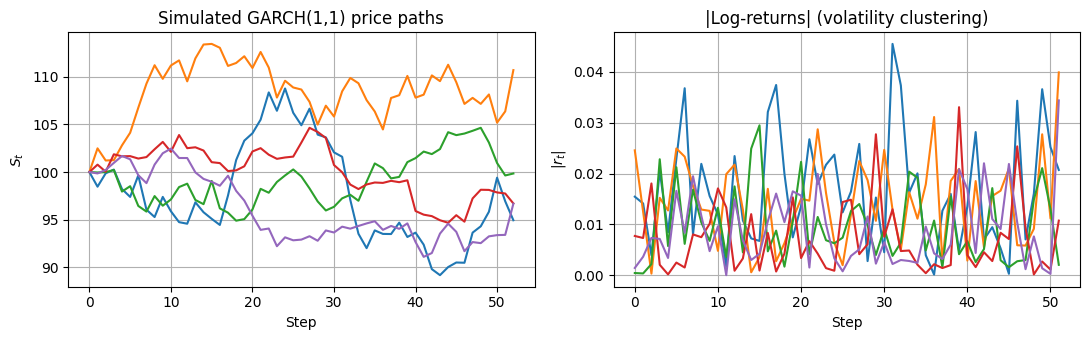

In [29]:
garch_demo = GARCH(S=100, r=0.0, T=1, omega=1e-5, alpha=0.10, beta=0.85)
print(f"alpha + beta (persistence): {garch_demo.alpha + garch_demo.beta:.2f}")
print(f"Long-run annualized vol: {np.sqrt(garch_demo.unconditional_variance() * 52):.2%}")

S_garch = garch_demo.GARCH_paths(N_steps=52, M_paths=5, seed=123)
returns = np.diff(np.log(S_garch), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(S_garch.T)
axes[0].set_title("Simulated GARCH(1,1) price paths")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("$S_t$")
axes[0].grid()

axes[1].plot(np.abs(returns.T))
axes[1].set_title("|Log-returns| (volatility clustering)")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("$|r_t|$")
axes[1].grid()

plt.tight_layout()
plt.show()

##### Hull-White

___
### Results

##### Parameters

In [14]:
S0, K, r, sigma, T = 100, 100, 0.0, 0.1, 1
bs_call_value = BlackScholes(S=S0, K=K, r=r, sigma=sigma, T=T)
initial_portfolio = bs_call_value.call_price()

# With Transaction costs
kappa = 0.0005

# Implied Call Volatility (Black-Scholes)
bs_implied_vol = BlackScholes(S=S0, K=K, r=r, sigma=None, T=T)
implied_vol = bs_implied_vol.implied_vol(price=initial_portfolio)


##### Simulated paths

In [ ]:
# paths_simulation = GARCH(S=S0, r=r, T=T, omega=1e-5, alpha=0.10, beta=0.85)
# S_train = paths_simulation.GARCH_paths(N_steps=52, M_paths=1000, seed=123)
# S_test  = paths_simulation.GARCH_paths(N_steps=52, M_paths=1000, seed=456)

In [15]:
paths_simulation = BlackScholes(S=S0, K=None, r=r, sigma=implied_vol, T=T)
S_train = paths_simulation.BS_paths(N_steps=52, M_paths=1000, seed=123)
S_test  = paths_simulation.BS_paths(N_steps=52, M_paths=1000, seed=456)

##### Without Transaction Costs

In [16]:
print(f"Call premium: {initial_portfolio:.4f}")

# Benchmark : Black-Scholes delta hedging
bs = BlackScholes(S=S0, K=K, r=r, sigma=implied_vol, T=T)
bs_pnl_notc, bs_deltas_notc = bs.delta_hedging(S_paths=S_test, 
                                               Initial_portfolio=initial_portfolio)

# Train
model = DeepHedging(K=K, r=r, T=T, kappa=0.0)
model.train_deep_hedger(S_train, initial_portfolio, risk='mse', alpha=0.95, lr=1e-3, n_epochs=300)

# Test
model_deltas_notc, model_pnl_notc = model.test_deephedging(S_test, initial_portfolio, risk='mse', alpha=0.95)

Call premium: 3.9878
Black-Scholes (No Transaction Costs) | mean P&L=-0.0147 | std=0.4833

Training | risk=mse | alpha=0.95 | kappa=0.0 | hidden=64 | lr=0.001 | epochs=300
Epoch    0 | loss = 10.5760 | mean P&L = -0.0783 | std = 3.2528 | mean TC = 0.0000


Epoch  100 | loss = 1.5990 | mean P&L = 0.0202 | std = 1.2650 | mean TC = 0.0000
Epoch  200 | loss = 0.5826 | mean P&L = 0.0097 | std = 0.7636 | mean TC = 0.0000
Epoch  300 | loss = 0.4100 | mean P&L = 0.0093 | std = 0.6406 | mean TC = 0.0000

Test | risk=mse | loss=0.4223 | mean P&L=-0.0086 | std=0.6501 | mean TC=0.0000


##### With Transaction Costs

In [17]:
print(f'Inital Portfolio Value: {initial_portfolio:.4f}')

# Benchmark : Black-Scholes delta hedging: Whalley and Wilmott
bs = BlackScholes(S=S0, K=K, r=r, sigma=implied_vol, T=T)
bs_pnl_tc, bs_deltas_tc = bs.delta_hedging(S_paths=S_test, 
                                               Initial_portfolio=initial_portfolio,
                                               transaction_cost='Leland',
                                               kappa=kappa,
                                               risk_aversion=1)

# Train
model = DeepHedging(K=K, r=r, T=T, kappa=kappa)
model.train_deep_hedger(S_train, initial_portfolio, risk='mse', alpha=0.95, lr=1e-3, n_epochs=300)

# Test
model_deltas_tc, model_pnl_tc = model.test_deephedging(S_test, initial_portfolio, risk='mse', alpha=0.95)

Inital Portfolio Value: 3.9878
Black-Scholes (No Transaction Costs) | mean P&L=-0.0146 | std=0.4835

Training | risk=mse | alpha=0.95 | kappa=0.0005 | hidden=64 | lr=0.001 | epochs=300
Epoch    0 | loss = 11.8122 | mean P&L = -0.1324 | std = 3.4361 | mean TC = 0.0242
Epoch  100 | loss = 5.5984 | mean P&L = -0.0717 | std = 2.3662 | mean TC = 0.0476
Epoch  200 | loss = 0.8855 | mean P&L = -0.0693 | std = 0.9389 | mean TC = 0.0772
Epoch  300 | loss = 0.5441 | mean P&L = -0.0832 | std = 0.7333 | mean TC = 0.0914

Test | risk=mse | loss=0.5755 | mean P&L=-0.1026 | std=0.7520 | mean TC=0.0920


### Results Analysis

In [18]:
import Ploting_DH as pdh

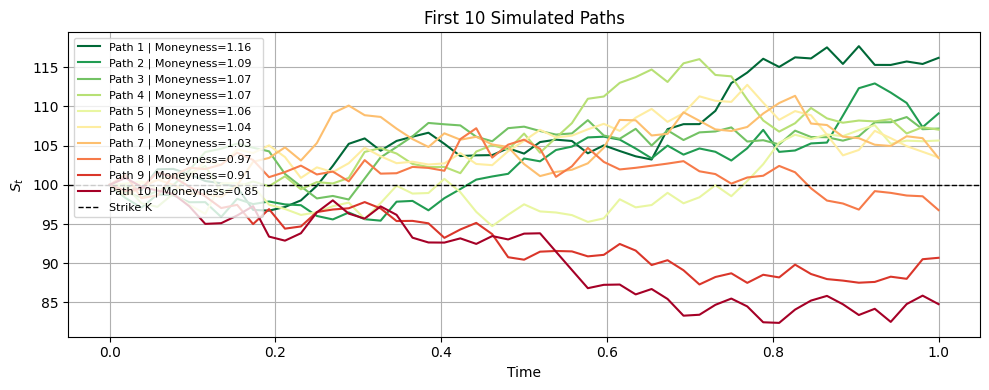

In [19]:
pdh.plot_n_paths(paths=S_test, n=10, K=K, T=T)

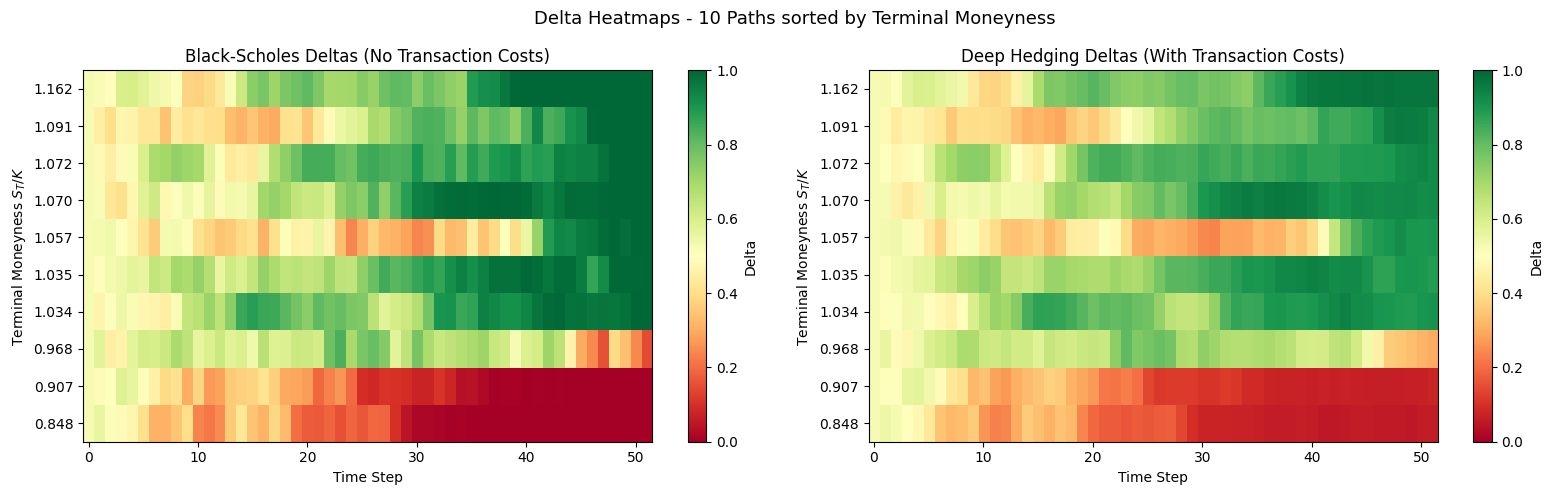

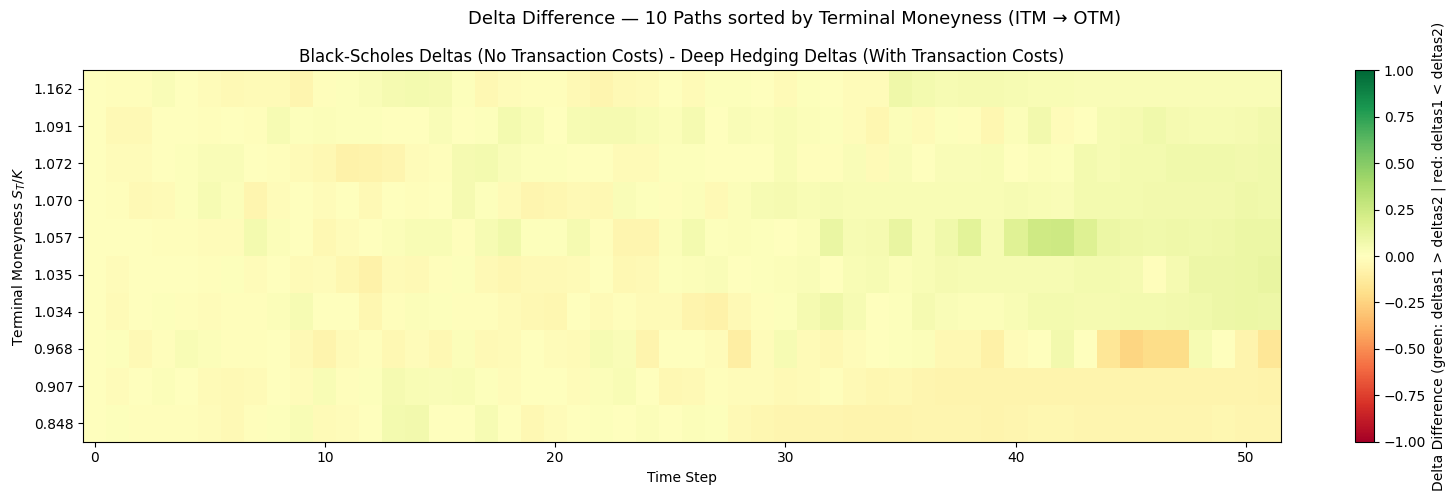

In [20]:
pdh.plot_n_deltas(S_test, bs_deltas_notc, model_deltas_tc.numpy(), n=10, K=K, T=T, m=0,
                  name1='Black-Scholes Deltas (No Transaction Costs)',
                  name2='Deep Hedging Deltas (With Transaction Costs)')

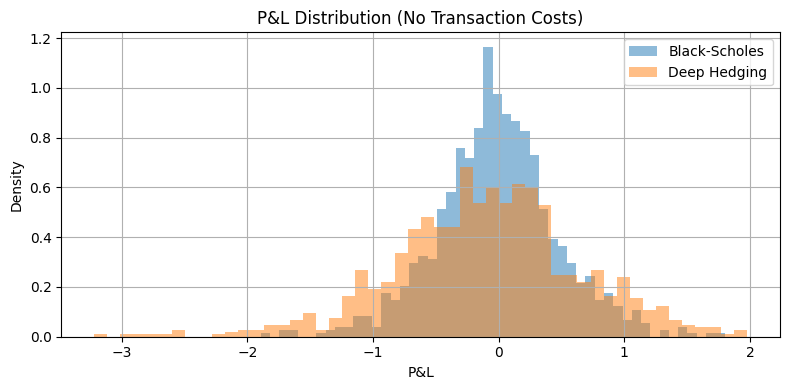

In [27]:
pdh.plot_pnl_histogram(bs_pnl_tc, model_pnl_tc.numpy(), label1='Black-Scholes', label2='Deep Hedging', title='P&L Distribution (No Transaction Costs)')

In [24]:
pdh.plot_correlation(bs_deltas_tc, model_deltas_tc.numpy(), T=T)

AttributeError: module 'Ploting_DH' has no attribute 'plot_correlation'